In [168]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Import du dataset

In [169]:
import glob

files = glob.glob("../data/eCO2mix_RTE_Annuel-Definitif_*.xls")

dfs = []
for f in files:
    df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

/tmp/ipykernel_3852/2610033358.py:7: DtypeWarning: Columns (18,19,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
/tmp/ipykernel_3852/2610033358.py:7: DtypeWarning: Columns (18,19,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
/tmp/ipykernel_3852/2610033358.py:7: DtypeWarning: Columns (18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
/tmp/ipykernel_3852/2610033358.py:7: DtypeWarning: Columns (36,37,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
/tmp/ipykernel_3852/2610033358.py:7: DtypeWarning: Columns (18,19,20

## Exploration

In [170]:
df.head(10)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2022-01-01,00:00,54615.0,51500.0,54200.0,89.0,14.0,2961.0,...,6300.0,1439.0,980.0,554.0,349.0,345.0,0.0,0.0,0.0,0.0
1,France,Données définitives,2022-01-01,00:15,NaN,51100.0,53750.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Données définitives,2022-01-01,00:30,53983.0,50700.0,53300.0,102.0,13.0,2676.0,...,6047.0,2494.0,1672.0,551.0,359.0,336.0,0.0,0.0,3180.0,0.0
3,France,Données définitives,2022-01-01,00:45,NaN,49850.0,52400.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,France,Données définitives,2022-01-01,01:00,52076.0,49000.0,51500.0,102.0,14.0,2675.0,...,5998.0,2388.0,633.0,557.0,356.0,339.0,0.0,0.0,3246.0,0.0
5,France,Données définitives,2022-01-01,01:15,NaN,49200.0,51850.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,France,Données définitives,2022-01-01,01:30,52199.0,49400.0,52200.0,102.0,13.0,2680.0,...,5951.0,2080.0,1167.0,563.0,349.0,345.0,0.0,0.0,3264.0,0.0
7,France,Données définitives,2022-01-01,01:45,NaN,49050.0,51700.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,France,Données définitives,2022-01-01,02:00,51764.0,48700.0,51200.0,102.0,13.0,2664.0,...,5901.0,2095.0,1072.0,564.0,345.0,335.0,0.0,0.0,3136.0,0.0
9,France,Données définitives,2022-01-01,02:15,NaN,47950.0,50700.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
# On retire les données au pas 00:15 et 00:45 car les données définitives fonctionnent par pas de 30 minutes
df = df.dropna(subset=["Consommation"])

In [172]:
df.head(10)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2022-01-01,00:00,54615.0,51500.0,54200.0,89.0,14.0,2961.0,...,6300.0,1439.0,980.0,554.0,349.0,345.0,0.0,0.0,0.0,0.0
2,France,Données définitives,2022-01-01,00:30,53983.0,50700.0,53300.0,102.0,13.0,2676.0,...,6047.0,2494.0,1672.0,551.0,359.0,336.0,0.0,0.0,3180.0,0.0
4,France,Données définitives,2022-01-01,01:00,52076.0,49000.0,51500.0,102.0,14.0,2675.0,...,5998.0,2388.0,633.0,557.0,356.0,339.0,0.0,0.0,3246.0,0.0
6,France,Données définitives,2022-01-01,01:30,52199.0,49400.0,52200.0,102.0,13.0,2680.0,...,5951.0,2080.0,1167.0,563.0,349.0,345.0,0.0,0.0,3264.0,0.0
8,France,Données définitives,2022-01-01,02:00,51764.0,48700.0,51200.0,102.0,13.0,2664.0,...,5901.0,2095.0,1072.0,564.0,345.0,335.0,0.0,0.0,3136.0,0.0
10,France,Données définitives,2022-01-01,02:30,51210.0,47200.0,50200.0,102.0,13.0,2679.0,...,5787.0,1604.0,396.0,569.0,354.0,334.0,0.0,0.0,3117.0,0.0
12,France,Données définitives,2022-01-01,03:00,49398.0,45500.0,48500.0,102.0,13.0,2676.0,...,5604.0,1279.0,142.0,566.0,344.0,336.0,0.0,0.0,3207.0,0.0
14,France,Données définitives,2022-01-01,03:30,48237.0,44400.0,47300.0,102.0,13.0,2681.0,...,5613.0,782.0,155.0,567.0,348.0,332.0,0.0,0.0,3326.0,0.0
16,France,Données définitives,2022-01-01,04:00,47017.0,43400.0,46100.0,102.0,13.0,2680.0,...,5621.0,757.0,154.0,568.0,353.0,335.0,0.0,0.0,3390.0,0.0
18,France,Données définitives,2022-01-01,04:30,46237.0,42900.0,45300.0,102.0,13.0,2688.0,...,5634.0,711.0,10.0,564.0,354.0,333.0,0.0,0.0,3577.0,0.0


In [173]:
df.describe()

,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,Taux de Co2
count,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000
mean,53182.062623,52745.233584,52674.724126,247.414763,773.723512,3345.550502,42387.903883,3413.601587,1346.135752,7154.372289,-783.641214,1017.790153,-5697.829346,42.275475
std,11806.156756,11796.397380,11775.292130,271.402821,1072.873358,2470.652257,7774.930696,3079.281338,2280.409705,2811.745630,984.664228,188.491789,4806.132133,23.235210
min,29124.000000,27500.000000,0.000000,18.000000,0.000000,234.000000,19164.000000,21.000000,0.000000,1387.000000,-4086.000000,441.000000,-20083.000000,7.000000
25%,44257.750000,43800.000000,43900.000000,87.000000,15.000000,1017.000000,37806.000000,1266.000000,0.000000,5007.750000,-1467.000000,901.000000,-9109.000000,24.000000
50%,51410.000000,51000.000000,50900.000000,146.000000,316.000000,2881.000000,41950.000000,2388.000000,20.000000,6932.000000,-207.000000,1071.000000,-6234.000000,38.000000
75%,61042.000000,60500.000000,60400.000000,326.000000,1192.000000,4956.250000,47327.250000,4524.000000,1916.000000,9025.000000,-21.000000,1153.000000,-2982.000000,57.000000
max,102098.000000,101000.000000,102700.000000,5926.000000,6265.000000,10591.000000,61712.000000,19744.000000,16658.000000,17947.000000,-1.000000,3252.000000,14608.000000,141.000000


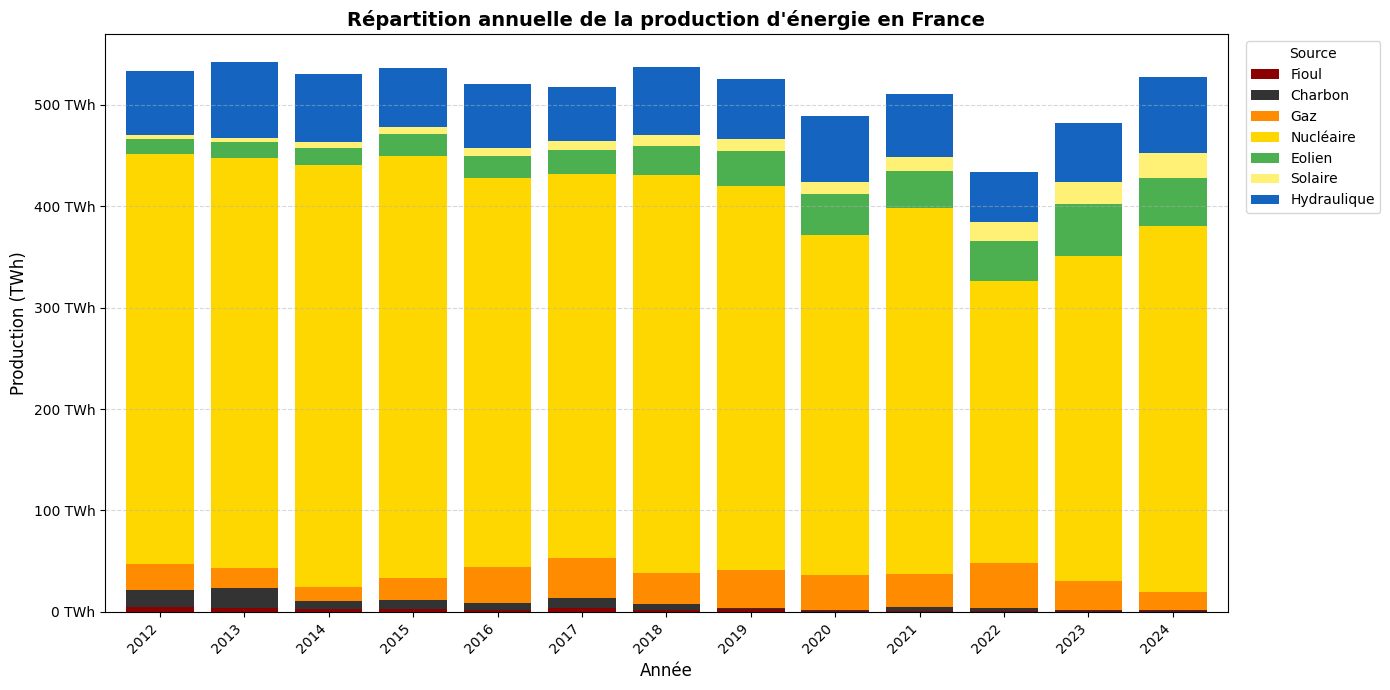

In [174]:
df_explo = df.copy()

df_explo["Date"] = pd.to_datetime(df_explo["Date"])
df_explo["Année"] = df_explo["Date"].dt.to_period("Y")

energy_cols = ["Fioul", "Charbon", "Gaz", "Nucléaire", "Eolien", "Solaire", "Hydraulique"]

annually = df_explo.groupby("Année")[energy_cols].sum() * 0.5 # 0.5 pour remettre en heure car nous avons des relevés toutes les 30 minutes

# Convertir en TWh pour lisibilité
annually_twh = annually / 1e6

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#8B0000", "#333333", "#FF8C00", "#FFD700", "#4CAF50", "#FFF176", "#1565C0"]

annually_twh.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8)

ax.set_title("Répartition annuelle de la production d'énergie en France", fontsize=14, fontweight="bold")
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Production (TWh)", fontsize=12)
ax.set_xticklabels([str(m) for m in annually_twh.index], rotation=45, ha="right")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} TWh"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

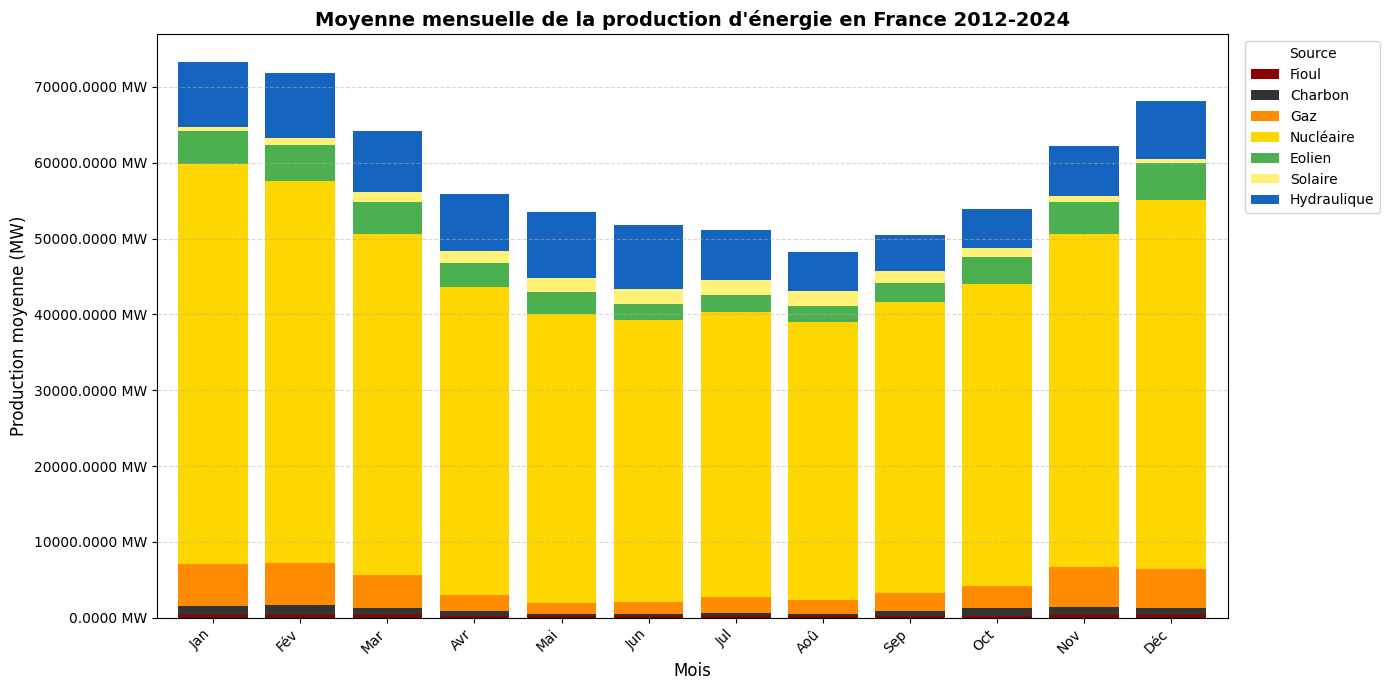

In [175]:
df_explo["Mois"] = df_explo["Date"].dt.month

monthly_avg = df_explo.groupby("Mois")[energy_cols].mean()

month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(figsize=(14, 7))

monthly_avg.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8)

ax.set_title("Moyenne mensuelle de la production d'énergie en France 2012-2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Production moyenne (MW)", fontsize=12)
ax.set_xticklabels(month_labels, rotation=45, ha="right")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.4f} MW"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Datacard

In [176]:
from datetime import datetime
import yaml

In [177]:
cols_ech = ["Ech. comm. Angleterre", "Ech. comm. Italie", "Ech. comm. Espagne", "Ech. comm. Suisse", "Ech. comm. Allemagne-Belgique"]
df[cols_ech] = df[cols_ech].apply(pd.to_numeric, errors='coerce')

In [178]:
n = len(df)

datacard = {
    "name": "eCO2mix_RTE_Annuel-Definitif",
    "version": "1.0",
    "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "domain": "energy",
    "period": "2012-2024",
    "data": {
        "instance_count": n,
        "feature_count": df.shape[1],
        "feature_list": {},
    }
}

description = {
    "Périmètre": "France",
    "Nature": "Données temps réel / Données consolidées / Données définitives",
    "Date": "Date du jour (jj/mm/aaaa)",
    "Heures": "Point horaire par pas de 30 minutes (hh:mm)",
    "Consommation": "Consommation en MW",
    "Prévision J-1": "Prévision J-1 de consommation en MW",
    "Prévision J": "Prévision J de consommation en MW",
    "Fioul": "Production fioul en MW",
    "Charbon": "Production charbon en MW",
    "Gaz": "Production gaz en MW",
    "Nucléaire": "Production nucléaire en MW",
    "Eolien": "Production éolienne en MW",
    "Solaire": "Production solaire en MW",
    "Hydraulique": "Production hydraulique en MW",
    "Pompage": "Pompage hydraulique en MW",
    "Bioénergies": "Production Bioénergies en MW",
    "Ech. physiques": "Solde imports/exports (flux physiques) en MW",
    "Taux de CO2": "Estimation des émissions de CO2 en g/kWh",
    "Ech. comm. Angleterre": "Solde imports/exports Angleterre (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Espagne": "Solde imports/exports Espagne (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Italie": "Solde imports/exports Italie (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Suisse": "Solde imports/exports Suisse (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Allemagne-Belgique": "Solde imports/exports Allemagne-Belgique (programmes d'échanges commerciaux) en MW",
    "Fioul - TAC": "Détail technologie turbine à combustion pour la filière fioul",
    "Fioul - Cogén.": "Détail technologie cogénération pour la filière fioul",
    "Fioul - Autres": "Détail autres technologies pour la filière fioul",
    "Gaz - TAC": "Détail technologie turbine à combustion pour la filière gaz",
    "Gaz - Cogén.": "Détail technologie cogénération pour la filière gaz",
    "Gaz - CCG": "Détail technologie cycle combiné gaz pour la filière gaz",
    "Gaz - Autres": "Détail autres technologies pour la filière gaz",
    "Hydraulique - Fil de l'eau + éclusée": "Détail technologie fil de l'eau et éclusée pour la filière hydraulique",
    "Hydraulique - Lacs": "Détail technologie lacs pour la filière hydraulique",
    "Hydraulique - STEP turbinage": "Détail technologie STEP turbinage pour la filière hydraulique",
    "Bioénergies - Déchets": "Détail technologie déchets pour la filière Bioénergies",
    "Bioénergies - Biomasse": "Détail technologie biomasse pour la filière Bioénergies",
    "Bioénergies - Biogaz": "Détail technologie biogaz pour la filière Bioénergies",
    "Stockage batterie": "Détail soutirage batteries",
    "Déstockage batterie": "Détail injections batteries",
    "Eolien terrestre": "Détail technologie éolien terrestre pour la filière Eolien",
    "Eolien offshore": "Détail technologie éolien en mer pour la filière Eolien",
}

count = df.count()
nunique = df.nunique()
missing = df.isna().sum()

df_stats = pd.DataFrame({
    "count": count.astype(int),
    "unique_count": nunique.astype(int),
    "duplicate_count": (count - nunique).astype(int),
    "duplicate_ratio": ((count - nunique) / count).round(2).astype(float),
    "missing_count": missing.astype(int),
    "missing_ratio": (missing / n).round(2).astype(float),
})
describe = df.describe().astype(float)

for idx, row in df_stats.iterrows():
    card = {
        "description": description.get(idx, ""),
        "type": str(df[idx].dtypes),
        "stats": row.to_dict(),
        "sample": df[idx].dropna().unique()[:5].tolist()
    }

    if pd.api.types.is_numeric_dtype(df[idx]):
        card.update({
            'stats': {
                **row.to_dict(),
                **describe[idx].to_dict()
            }
        })

    datacard["data"]["feature_list"][idx] = card

In [179]:
with open("../data/raw_data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(datacard, f, sort_keys=False, allow_unicode=True)

## Data analyse

In [180]:
df.columns

Index(['Périmètre', 'Nature', 'Date', 'Heures', 'Consommation',
       'Prévision J-1', 'Prévision J', 'Fioul', 'Charbon', 'Gaz', 'Nucléaire',
       'Eolien', 'Solaire', 'Hydraulique', 'Pompage', 'Bioénergies',
       'Ech. physiques', 'Taux de Co2', 'Ech. comm. Angleterre',
       'Ech. comm. Espagne', 'Ech. comm. Italie', 'Ech. comm. Suisse',
       'Ech. comm. Allemagne-Belgique', 'Fioul - TAC', 'Fioul - Cogén.',
       'Fioul - Autres', 'Gaz - TAC', 'Gaz - Cogén.', 'Gaz - CCG',
       'Gaz - Autres', 'Hydraulique - Fil de l?eau + éclusée',
       'Hydraulique - Lacs', 'Hydraulique - STEP turbinage',
       'Bioénergies - Déchets', 'Bioénergies - Biomasse',
       'Bioénergies - Biogaz', ' Stockage batterie', 'Déstockage batterie',
       'Eolien terrestre', 'Eolien offshore'],
      dtype='object')

In [181]:
# Les colonnes qui ne contiennent qu'une seule même valeur pour toutes ses observations
df.columns[df.nunique() == 1]

Index(['Périmètre', 'Nature'], dtype='object')

In [182]:
df_analyse = df.copy() 

energy_cols = ["Fioul", "Charbon", "Gaz", "Nucléaire", "Eolien", "Solaire", "Hydraulique", "Bioénergies"]

colors = [
    '#E63946',
    '#2196F3',
    '#2A9D8F',
    '#F4A261',
    '#8338EC',
    '#FFBE0B',
    '#FB5607',
    '#3A86FF',
    '#06D6A0',
    '#FF006E',
]

df_analyse["Production"] = df[energy_cols].sum(axis=1)

def add_column(groupby, label, color):
    ax.fill_between(range(len(groupby)), 0, groupby[label], alpha=0.1, color=color)
    ax.plot(groupby[label], color=color, label=label)

/tmp/ipykernel_3852/2934145249.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_avg = df_analyse.groupby("Heures")[["Consommation", "Production"]].mean().sort_index()


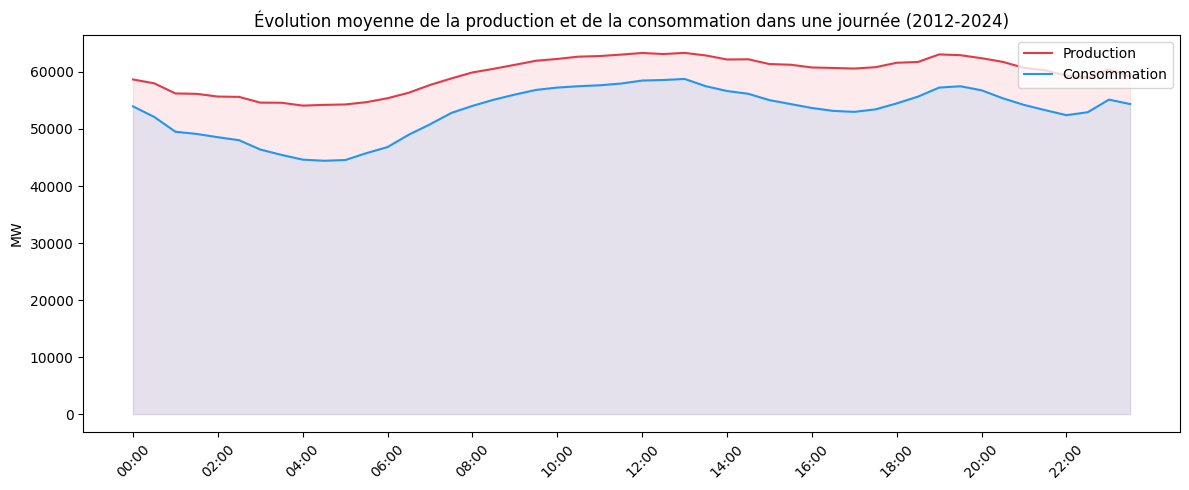

In [183]:
df_analyse["Heures"] = pd.Categorical(df["Heures"], categories=sorted(df["Heures"].unique()), ordered=True)

hourly_avg = df_analyse.groupby("Heures")[["Consommation", "Production"]].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

add_column(hourly_avg, "Production", colors[0])
add_column(hourly_avg, "Consommation", colors[1])

ax.set_xticks(range(0, 48, 4))
ax.set_xticklabels(hourly_avg.index[::4], rotation=45)
ax.set_ylabel("MW")
ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
plt.title("Évolution moyenne de la production et de la consommation dans une journée (2012-2024)")
plt.tight_layout()
plt.show()

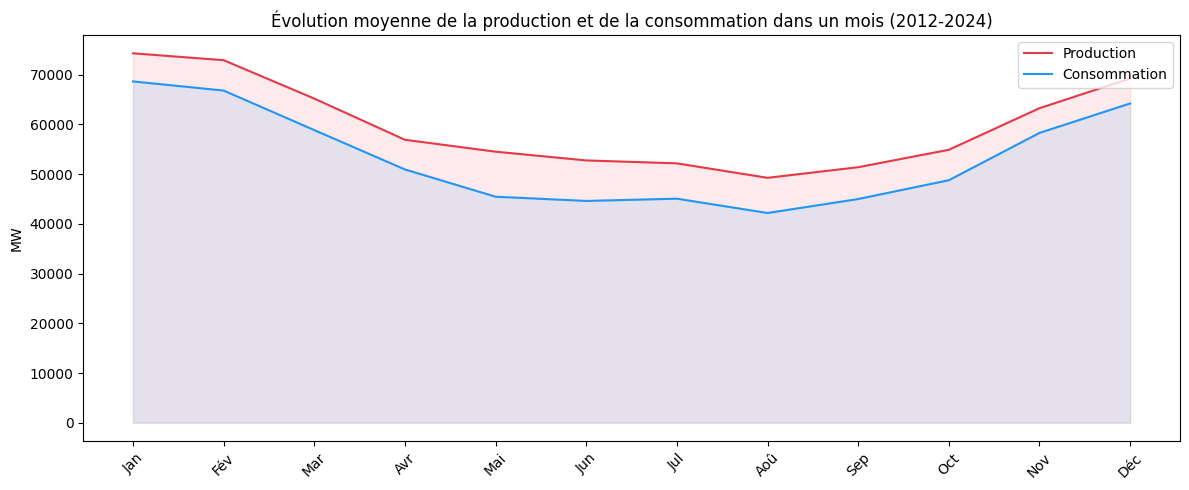

In [184]:
df_analyse["Date"] = pd.to_datetime(df_analyse["Date"])
df_analyse["Mois"] = df_analyse["Date"].dt.month - 1
month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

monthly_avg = df_analyse.groupby("Mois")[["Consommation", "Production"]].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

add_column(monthly_avg, "Production", colors[0])
add_column(monthly_avg, "Consommation", colors[1])

ax.set_xticks(range(12), month_labels, rotation=45)
ax.set_ylabel("MW")
ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
plt.title("Évolution moyenne de la production et de la consommation dans un mois (2012-2024)")
plt.tight_layout()
plt.show()

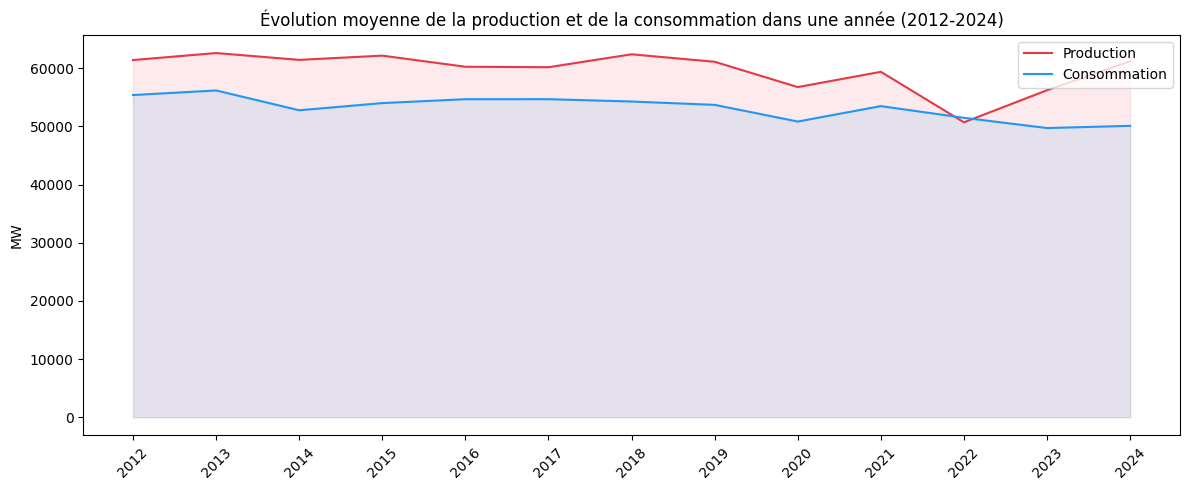

In [185]:
df_analyse["Date"] = pd.to_datetime(df_analyse["Date"])
df_analyse["Année"] = df_analyse["Date"].dt.to_period("Y")

yearly_avg = df_analyse.groupby("Année")[["Consommation", "Production"]].mean().reset_index()
year_labels = sorted(df_analyse["Année"].unique())

fig, ax = plt.subplots(figsize=(12, 5))

add_column(yearly_avg, "Production", colors[0])
add_column(yearly_avg, "Consommation", colors[1])

ax.set_xticks(range(len(year_labels)), year_labels, rotation=45)
ax.set_ylabel("MW")
ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
plt.title("Évolution moyenne de la production et de la consommation dans une année (2012-2024)")
plt.tight_layout()
plt.show()

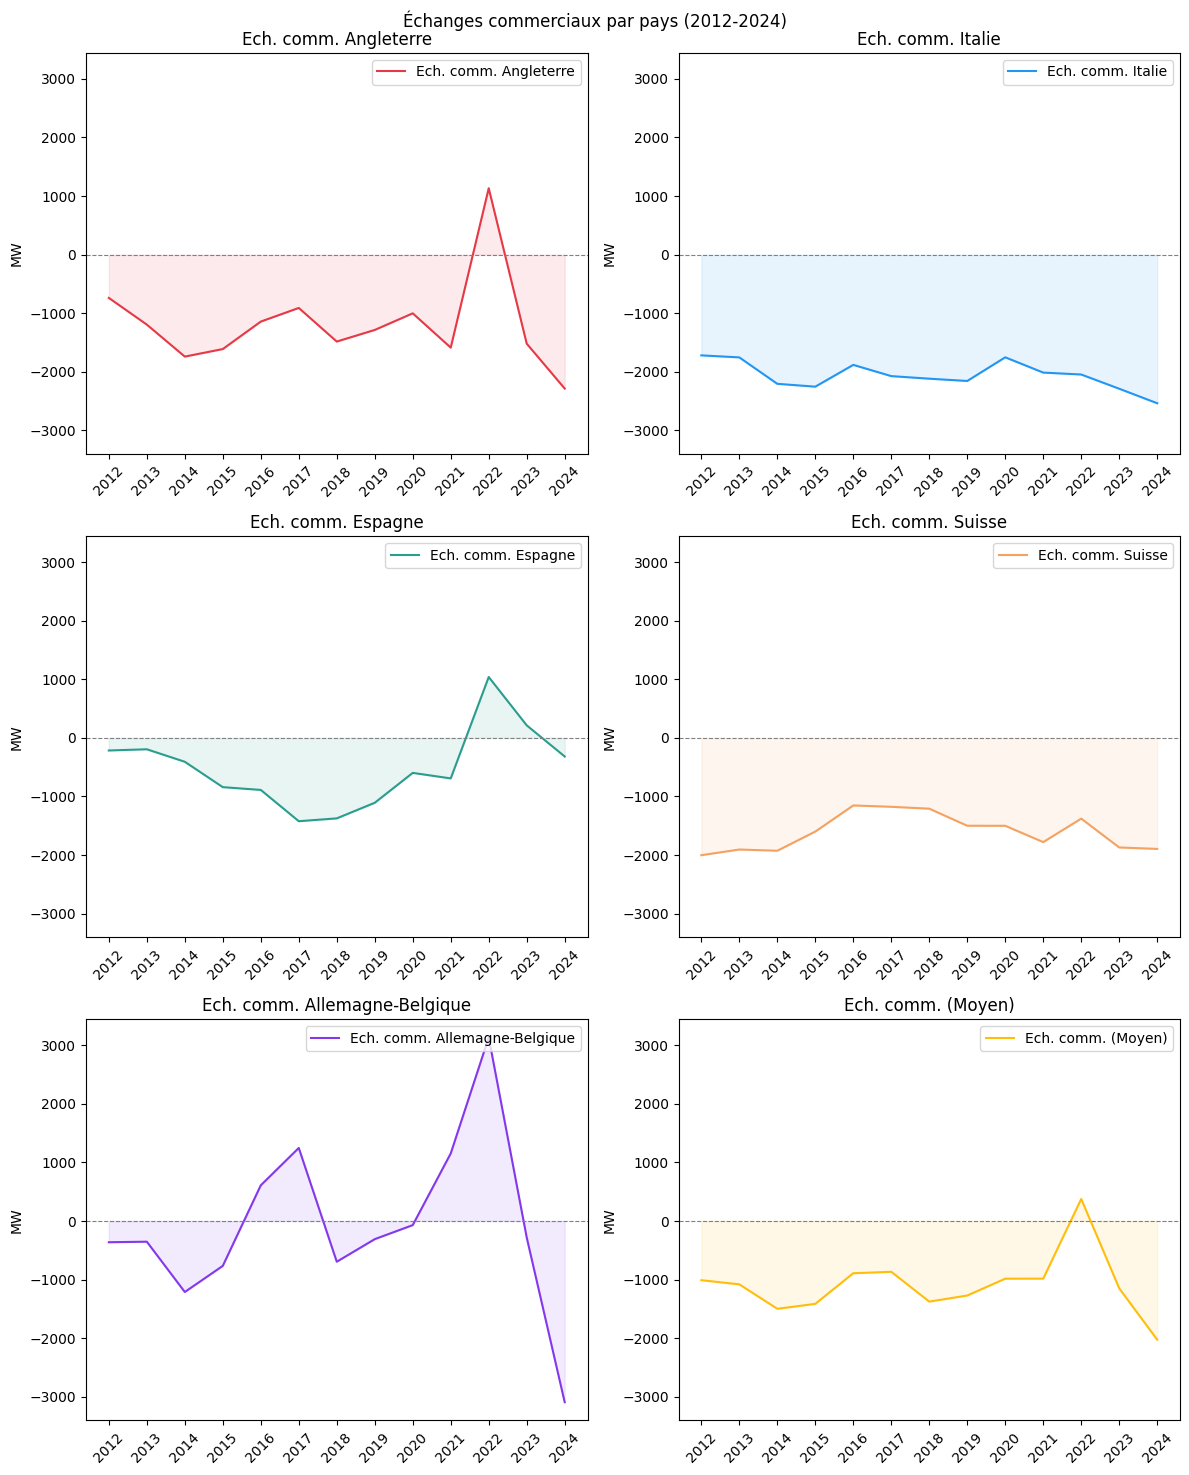

In [189]:
df_analyse["Date"] = pd.to_datetime(df_analyse["Date"])
df_analyse["Année"] = df_analyse["Date"].dt.to_period("Y")

df_analyse["Ech. comm. (Moyen)"] = df_analyse[cols_ech].mean(axis=1)

cols_ech = ["Ech. comm. Angleterre", "Ech. comm. Italie", "Ech. comm. Espagne", "Ech. comm. Suisse", "Ech. comm. Allemagne-Belgique", "Ech. comm. (Moyen)"]

exchange_avg = df_analyse.groupby("Année")[cols_ech].mean().reset_index()
year_labels = sorted(df_analyse["Année"].unique())

fig, axes = plt.subplots(3, 2, figsize=(12, 15), sharey=True)

for ax, (col, color) in zip(axes.flatten(), zip(cols_ech, colors)):
    add_column(exchange_avg, col, color)
    ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(col)
    ax.set_xticks(range(len(year_labels)), year_labels, rotation=45)
    ax.set_ylabel("MW")
    ax.tick_params(labelleft=True)

plt.suptitle("Échanges commerciaux par pays (2012-2024)")
plt.tight_layout()

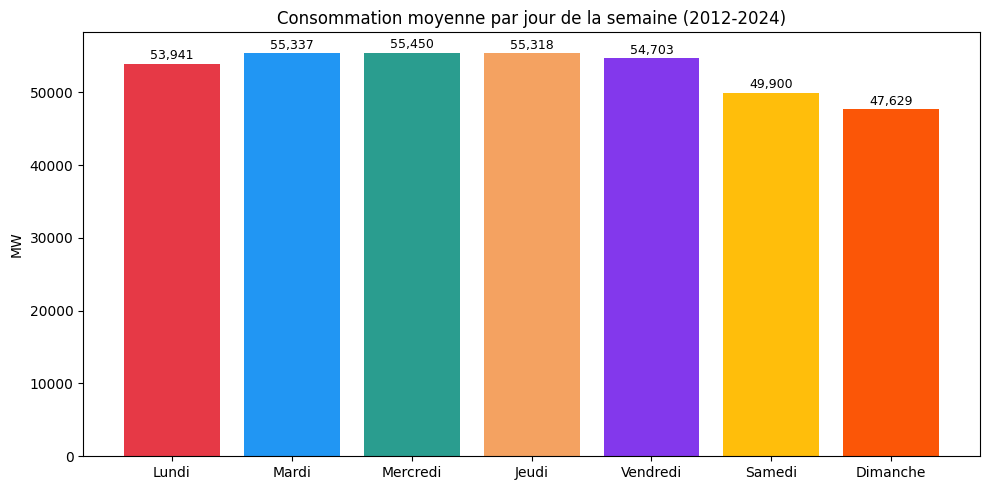

In [191]:
df_analyse["Date"] = pd.to_datetime(df_analyse["Date"])
df_analyse["Jour"] = df_analyse["Date"].dt.dayofweek

jour_labels = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

daily_avg = df_analyse.groupby("Jour")["Consommation"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(daily_avg["Jour"], daily_avg["Consommation"], color=colors[:7])
ax.set_xticks(range(7), jour_labels)
ax.set_ylabel("MW")
ax.set_title("Consommation moyenne par jour de la semaine (2012-2024)")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()